In [2]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np

# Load NSL-KDD dataset
column_names = ["duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes", "land", "wrong_fragment",
                "urgent", "hot", "num_failed_logins", "logged_in", "num_compromised", "root_shell", "su_attempted",
                "num_root", "num_file_creations", "num_shells", "num_access_files", "num_outbound_cmds", "is_host_login",
                "is_guest_login", "count", "srv_count", "serror_rate", "srv_serror_rate", "rerror_rate", "srv_rerror_rate",
                "same_srv_rate", "diff_srv_rate", "srv_diff_host_rate", "dst_host_count", "dst_host_srv_count",
                "dst_host_same_srv_rate", "dst_host_diff_srv_rate", "dst_host_same_src_port_rate", "dst_host_srv_diff_host_rate",
                "dst_host_serror_rate", "dst_host_srv_serror_rate", "dst_host_rerror_rate", "dst_host_srv_rerror_rate", "label", "drop"]

# Load data from CSV
df = pd.read_csv('KDDTrain+.txt', header=None, names=column_names)

In [3]:
# Encode categorical variables (protocol_type, service, and flag)
label_encoder = LabelEncoder()

# Apply LabelEncoder to the categorical columns
df['protocol_type'] = label_encoder.fit_transform(df['protocol_type'])
df['service'] = label_encoder.fit_transform(df['service'])
df['flag'] = label_encoder.fit_transform(df['flag'])

# Convert the label column to binary (0: normal, 1: attack)
df['label'] = df['label'].apply(lambda x: 1 if x != 'normal' else 0)

# Separate features and labels
X = df.drop('label', axis=1).values
y = df['label'].values

# Normalize the feature values using StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split the dataset into training, validation, and test sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Print the shape of the datasets
print(f"Training data shape: {X_train.shape}")
print(f"Validation data shape: {X_val.shape}")
print(f"Test data shape: {X_test.shape}")



Training data shape: (88181, 42)
Validation data shape: (18896, 42)
Test data shape: (18896, 42)


In [4]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
from tensorflow.keras.optimizers import Adam

# Build the RNN model
model = Sequential()

# Add LSTM layers
model.add(LSTM(64, input_shape=(X_train.shape[1], 1), activation='relu', return_sequences=True))
model.add(Dropout(0.2))
model.add(LSTM(32, activation='relu'))
model.add(Dropout(0.2))

# Add the output layer
model.add(Dense(1, activation='sigmoid'))

# Compile the model
model.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])


c:\Users\user12\Anaconda3\envs\vivek\lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [5]:
# Reshape input data for RNN
X_train = np.expand_dims(X_train, axis=-1)
X_val = np.expand_dims(X_val, axis=-1)
X_test = np.expand_dims(X_test, axis=-1)


In [6]:
# Train the model
history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=10, batch_size=32)

# Evaluate on test set
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")


Epoch 1/10
2756/2756 ━━━━━━━━━━━━━━━━━━━━ 39s 13ms/step - accuracy: 0.8230 - loss: 1.4738 - val_accuracy: 0.9445 - val_loss: 0.1401
Epoch 2/10
2756/2756 ━━━━━━━━━━━━━━━━━━━━ 37s 13ms/step - accuracy: 0.9001 - loss: 12.8555 - val_accuracy: 0.9307 - val_loss: 0.4382
Epoch 3/10
2756/2756 ━━━━━━━━━━━━━━━━━━━━ 37s 13ms/step - accuracy: 0.9345 - loss: 0.5765 - val_accuracy: 0.9697 - val_loss: 0.2050
Epoch 4/10
2756/2756 ━━━━━━━━━━━━━━━━━━━━ 37s 13ms/step - accuracy: 0.9618 - loss: 0.2537 - val_accuracy: 0.9747 - val_loss: 0.0717
Epoch 5/10
2756/2756 ━━━━━━━━━━━━━━━━━━━━ 37s 13ms/step - accuracy: 0.9699 - loss: 0.0949 - val_accuracy: 0.9845 - val_loss: 0.0599
Epoch 6/10
2756/2756 ━━━━━━━━━━━━━━━━━━━━ 37s 14ms/step - accuracy: 0.9749 - loss: 0.0858 - val_accuracy: 0.9833 - val_loss: 0.0535
Epoch 7/10
2756/2756 ━━━━━━━━━━━━━━━━━━━━ 38s 14ms/step - accuracy: 0.9756 - loss: 0.0719 - val_accuracy: 0.9852 - val_loss: 0.0411
Epoch 8/10
2756/2756 ━━━━━━━━━━━━━━━━━━━━ 38s 14ms/step - accuracy: 0.9804 

591/591 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step
Confusion Matrix:
[[9857  129]
 [  42 8868]]
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      9986
           1       0.99      1.00      0.99      8910

    accuracy                           0.99     18896
   macro avg       0.99      0.99      0.99     18896
weighted avg       0.99      0.99      0.99     18896



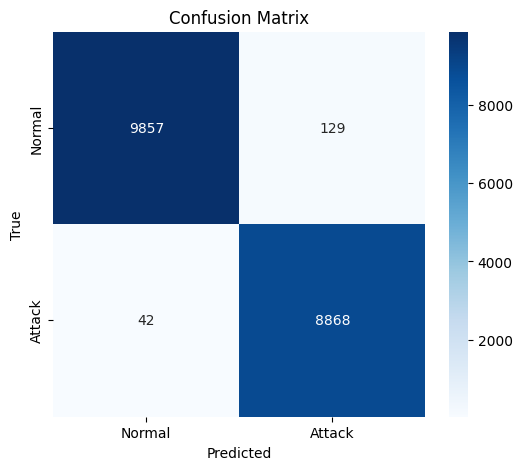

591/591 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step


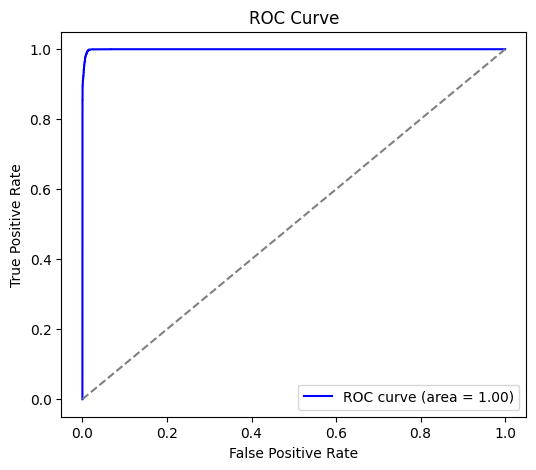

591/591 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step


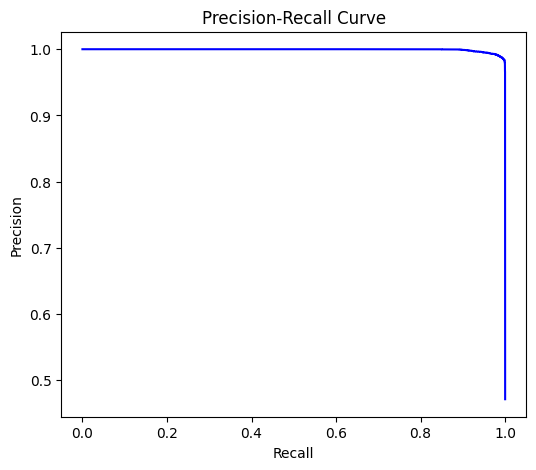

In [7]:
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve
import matplotlib.pyplot as plt
import seaborn as sns

# Predictions on test data
y_pred = (model.predict(X_test) > 0.5).astype(int)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print(f"Confusion Matrix:\n{cm}")

# Classification Report (Precision, Recall, F1-Score)
print(classification_report(y_test, y_pred))

# Plot Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Attack'], yticklabels=['Normal', 'Attack'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, model.predict(X_test))
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='b', label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, model.predict(X_test))

plt.figure(figsize=(6, 5))
plt.plot(recall, precision, color='b')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()
